In [3]:
import sys
assert sys.version_info >= (3,5) 

In [4]:
import sklearn
assert sklearn.__version__ >= "0.20"

In [5]:
import numpy as np
import os

In [6]:
np.random.seed(42) # to make this notebook's output stable across runs

In [7]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize = 14)
mpl.rc('xtick', labelsize = 12)
mpl.rc('ytick', labelsize = 12)

# MNIST

### Importing and Visualising Data

In [8]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)  

In [40]:
# Loaded as a dictionary
mnist.keys() 

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [50]:
mnist['data'].shape # 70,000 images and 784 features (28 x 28 pixels)

(70000, 784)

In [48]:
mnist['target'].shape

(70000,)

In [10]:
X,y = mnist['data'],mnist['target']
print(f"Data's shape: {X.shape}")
print(f"Target's shape: {y.shape}")

Data's shape: (70000, 784)
Target's shape: (70000,)


In [11]:
some_digit = X[0]
some_digit

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [12]:
some_digit_image = some_digit.reshape(28,28)
some_digit_image

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

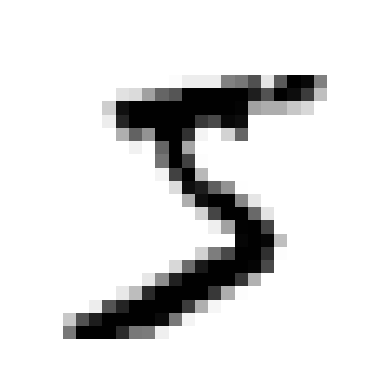

In [13]:
# image show
plt.imshow(some_digit_image,cmap='binary',interpolation='nearest')
plt.axis('off') # to remove x,y axes
plt.show()

In [14]:
y[0] # target is 5 (string)

'5'

In [15]:
# Concert the targerts to numbers as ml algos expect numbers
y = y.astype(np.uint8) # Unsigned Integer (8-bit).

In [16]:
y[0]

np.uint8(5)

In [17]:
# Function for ploting an individual digit
def plot_digit(data):
    image = data.reshape(28,28)
    plt.imshow(image, cmap='binary', interpolation='nearest')
    plt.axis('off')
    plt.show()

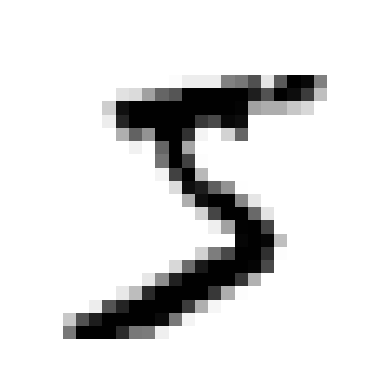

In [18]:
plot_digit(X[0])

### Creating Test set

The MNIST dataset is actually already split into a training set (the first 60,000
images) and a test set (the last 10,000 images):

In [19]:
X_train, X_test, y_train, y_test = X[:60000],X[60000:],y[:60000],y[60000:]

### Tarining a Binary Classifier (SGDClassifier)

Binary classifier is capable of distinguishing between just two classes(yes or no), (eg: 5 and not-5)

In [22]:
# target vectors for binary classification
y_train_5 = (y_train == 5) # True for all 5's and False for others
y_test_5 = (y_test == 5)

In [23]:
y_train_5

array([ True, False, False, ...,  True, False, False])

In [24]:
from sklearn.linear_model import SGDClassifier

In [25]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(random_state=42)

In [112]:
sgd_clf.predict([X[0]]) # 5

array([ True])

In [113]:
sgd_clf.predict([X[10]]) # 3

array([False])

## Performance Measures

### Cross-Validation

In [26]:
# Implemeting own cross validation function using stratified sampling
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

In [116]:
skfolds = StratifiedKFold(n_splits=3, random_state=42,shuffle=True)

In [117]:
for train_index, test_index in skfolds.split(X_train,y_train_5):
    clone_clf = clone(sgd_clf)

    X_train_fold = X_train[train_index]
    X_test_fold = X_train[test_index]
    y_train_fold = y_train_5[train_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_fold,y_train_fold)
    y_pred = clone_clf.predict(X_test_fold)
    print(sum(y_pred == y_test_fold) / len(y_pred))

0.9669
0.91625
0.96785


In [27]:
# using cross_val_score() --> does the same thing in one line
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

### Confusion Matrix

In [126]:
# cross_val_predict() does the same thing as cross_val_score but returns predictions instead of scores

In [42]:
from sklearn.model_selection import cross_val_predict

In [67]:
y_train_pred = cross_val_predict(sgd_clf,X_train,y_train_5,cv = 5)

In [68]:
y_train_pred

array([ True, False, False, ...,  True, False, False])

In [69]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred) 

array([[53115,  1464],
       [  916,  4505]])

In [125]:
# Let's say we got perfect predictions (only main diagonal will have non zero values)
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5,y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

### Presision and Recall

In [128]:
from sklearn.metrics import precision_score, recall_score

In [130]:
precision_score(y_train_5,y_train_pred)

0.7547327860613168

In [133]:
4505/(4505 + 1464) # TP/(TP+FP)

0.7547327860613168

In [131]:
recall_score(y_train_5,y_train_pred)

0.8310274857037447

In [134]:
4505/(4505 + 916) # TP/(TP+FN)

0.8310274857037447

### F1 Score

In [135]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7910447761194029

In [137]:
(2*precision_score(y_train_5,y_train_pred)*recall_score(y_train_5,y_train_pred)) / (precision_score(y_train_5,y_train_pred)+recall_score(y_train_5,y_train_pred))

0.791044776119403

### Precision/Recall Trade-off

In [141]:
# decision_function returns score
y_score_some_digit = sgd_clf.decision_function([some_digit])
y_score_some_digit

array([2164.22030239])

In [143]:
# SGDClassifier uses prediction 0
y_score_some_digit > 0

array([ True])

In [144]:
# Specifying method as decision_function in cross_val_predict returns the score of each instance instead of prediction
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')

In [145]:
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447])

### Precision Recall Curve

In [146]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5,y_scores)

In [147]:
precisions

array([0.09035   , 0.09035151, 0.09035301, ..., 1.        , 1.        ,
       1.        ])

In [148]:
recalls

array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
       3.68935621e-04, 1.84467810e-04, 0.00000000e+00])

In [149]:
thresholds

array([-146348.56726174, -142300.00705404, -137588.97581744, ...,
         38871.26391927,   42216.05562787,   49441.43765905])

In [152]:
# when threshold very low recall is high and precision is low and vice versa

In [154]:
print(len(precisions),len(recalls),len(thresholds)) # Scikit-Learn adds a final "boundary" value to the end of precision and recall arrays

60001 60001 60000


In [167]:
# Function to plot the curve
def plot_precision_recall_vs_threshold(precisions,recalls,thresholds):
    plt.plot(thresholds,precisions[:-1],'b--',label='precision')
    plt.plot(thresholds,recalls[:-1],'g',label='recall')
    plt.xlabel('Thresholds',fontsize=16)
    

    plt.axis([-50000,50000,0,1])
    plt.grid(True)
    plt.legend(loc='center right',fontsize=16)
    plt.show()

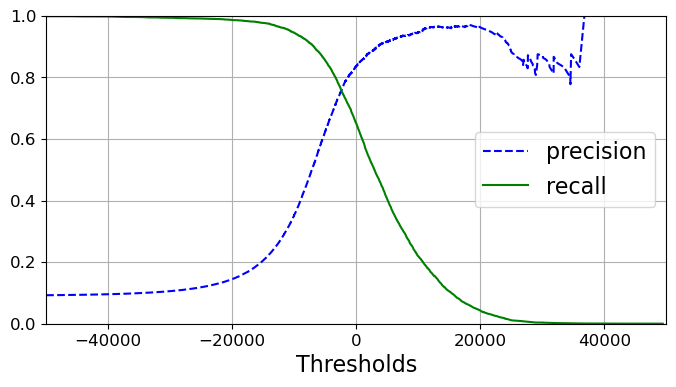

In [170]:
plt.figure(figsize=(8,4)) # figsize(width,height)
plot_precision_recall_vs_threshold(precisions,recalls,thresholds)

In [190]:
# Function to plot precision vs recall
def plot_precision_vs_recall(precisions,recalls):
    plt.figure(figsize=(8,4))
    plt.plot(recalls,precisions,'b')
    plt.ylabel("Precision")
    plt.xlabel('Recall')
    plt.grid(True)
    plt.axis([0,1,0,1])
    plt.show()

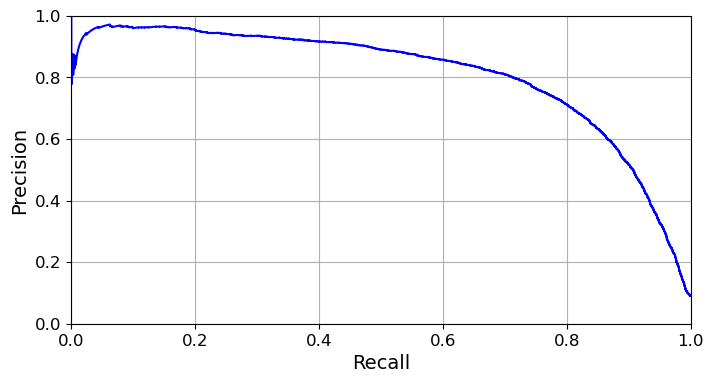

In [191]:
plot_precision_vs_recall(precisions,recalls)

In [202]:
# Objective: Finding a classifier with 90% precision
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)] # Minimum threshold for 90% precision
threshold_90_precision

np.float64(3370.0194991439557)

In [204]:
y_train_pred_90 = (y_scores >= threshold_90_precision)
y_train_pred_90

array([False, False, False, ...,  True, False, False])

In [205]:
precision_score(y_train_5,y_train_pred_90)

0.9000345901072293

In [206]:
recall_score(y_train_5,y_train_pred_90)

0.4799852425751706

### ROC Curve

In [207]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5,y_scores)

In [208]:
fpr

array([0.        , 0.        , 0.        , ..., 0.99937705, 0.99937705,
       1.        ])

In [209]:
tpr

array([0.00000000e+00, 1.84467810e-04, 9.22339052e-04, ...,
       9.99815532e-01, 1.00000000e+00, 1.00000000e+00])

In [210]:
thresholds

array([             inf,   49441.43765905,   36801.60697028, ...,
       -105763.22240074, -106527.45300471, -146348.56726174])

In [232]:
def plot_roc_curve(fpr,tpr,label=None):
    plt.plot(fpr,tpr,linewidth=2,label=label)
    plt.plot([0,1],[0,1],'k--')
    plt.axis([0,1,0,1])
    plt.grid(True)
    plt.xlabel('False Positive Rate',fontsize=16)
    plt.ylabel('True Positive Rate (Recall)',fontsize=16)
    

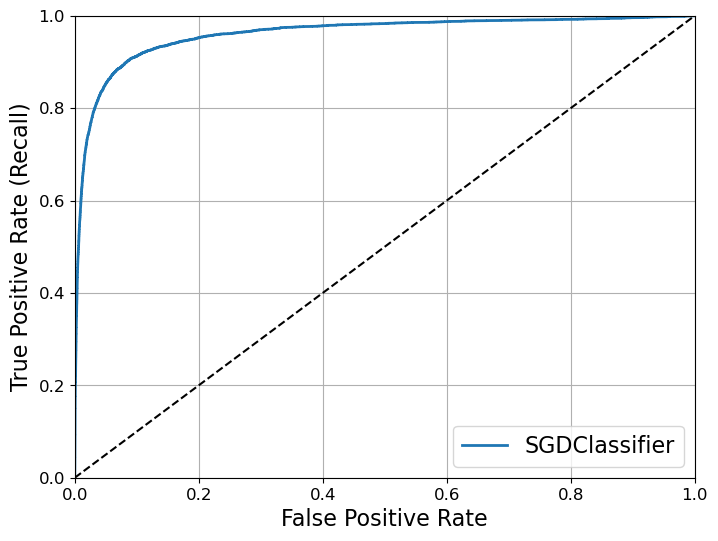

In [233]:
plt.figure(figsize=(8,6))
plot_roc_curve(fpr,tpr,'SGDClassifier')
plt.legend(loc='lower right',fontsize=16)
plt.show()

In [220]:
# AUC of a good binary classifier will tend towards 1
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

np.float64(0.9604938554008616)

### Comparison with Random Forest Classifier

In [221]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)

In [224]:
y_probas_forest = cross_val_predict(forest_clf,X_train,y_train_5,cv=3,method='predict_proba')

In [226]:
# A 2D NumPy array where each row represents an image and each column represents a class(no/yes) probabilities
y_probas_forest

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       ...,
       [0.02, 0.98],
       [0.92, 0.08],
       [0.94, 0.06]])

In [229]:
# Keeping scores equal to the probability of positive class
y_scores_forest = y_probas_forest[:,1]
y_scores_forest

array([0.89, 0.01, 0.04, ..., 0.98, 0.08, 0.06])

In [230]:
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5,y_scores_forest)

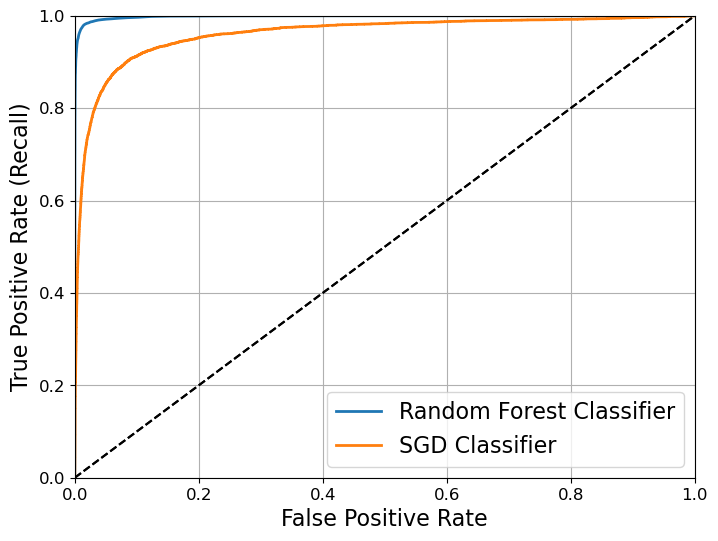

In [235]:
plt.figure(figsize=(8,6))
plot_roc_curve(fpr_forest,tpr_forest,label='Random Forest Classifier')
plot_roc_curve(fpr,tpr,label='SGD Classifier')
plt.legend(loc='lower right',fontsize=16)
plt.show()

In [236]:
# AUC for Forest Classifier
roc_auc_score(y_train_5,y_scores_forest)

np.float64(0.9983436731328145)

In [237]:
# Precsion and Recall for this model will be high
y_train_pred_forest = cross_val_predict(forest_clf,X_train,y_train_5,cv=3)

In [241]:
precision_score(y_train_5,y_train_pred_forest)

0.9905083315756169

In [242]:
recall_score(y_train_5,y_train_pred_forest)

0.8662608374838591

## Multiclass Classification

### SVM (OneVsOne and OneVsRest)

In [28]:
# Using SVM for 1000 instances only
from sklearn.svm import SVC
svm_clf = SVC(gamma="auto", random_state=42)
svm_clf.fit(X_train[:1000],y_train[:1000]) # uses OvO Strategy (One vs One) internally

SVC(gamma='auto', random_state=42)

In [29]:
svm_clf.predict([some_digit])

array([5], dtype=uint8)

In [30]:
svm_clf.classes_ # Target classes

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [31]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores # 5 will have highest score

array([[ 2.81585438,  7.09167958,  3.82972099,  0.79365551,  5.8885703 ,
         9.29718395,  1.79862509,  8.10392157, -0.228207  ,  4.83753243]])

In [32]:
svm_clf.classes_[np.argmax(some_digit_scores)]

np.uint8(5)

In [33]:
# Forcefully using One vs Rest Strategy
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC(gamma='auto',random_state=42))
ovr_clf.fit(X_train[:1000],y_train[:1000])

OneVsRestClassifier(estimator=SVC(gamma='auto', random_state=42))

In [34]:
ovr_clf.predict([some_digit])

array([5], dtype=uint8)

In [35]:
ovr_clf.estimators_

[SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42),
 SVC(gamma='auto', random_state=42)]

In [36]:
len(ovr_clf.estimators_) # Trained 10 models for each individual class

10

In [37]:
ovr_clf.decision_function([some_digit])

array([[-0.9990256 , -0.99963766, -0.99949709, -0.99902667, -0.99986906,
         0.10132159, -0.99976287, -0.99933311, -0.99943631, -0.99924045]])

In [38]:
ovr_clf.classes_[np.argmax(ovr_clf.decision_function([some_digit]))]

np.uint8(5)

### SGDClassifier

In [45]:
cross_val_predict(sgd_clf,X_train[:1000],y_train[:1000],cv=3)

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 8, 3, 6, 1, 7, 9, 8, 6, 9, 4, 0,
       9, 1, 5, 2, 9, 3, 2, 9, 3, 8, 6, 7, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9,
       3, 9, 9, 5, 5, 3, 3, 0, 7, 5, 7, 7, 0, 9, 4, 1, 4, 4, 6, 0, 4, 5,
       6, 1, 0, 0, 2, 7, 1, 6, 3, 0, 8, 1, 1, 7, 8, 0, 2, 6, 7, 8, 3, 9,
       0, 4, 6, 7, 9, 6, 8, 0, 7, 8, 3, 7, 9, 7, 1, 7, 1, 1, 6, 3, 0, 6,
       9, 3, 1, 1, 0, 4, 9, 2, 0, 0, 2, 0, 2, 7, 1, 8, 6, 4, 1, 6, 3, 4,
       3, 9, 5, 3, 3, 7, 5, 4, 7, 7, 4, 2, 8, 5, 8, 6, 8, 3, 9, 6, 1, 9,
       7, 6, 0, 3, 4, 2, 7, 3, 9, 4, 4, 6, 4, 9, 7, 0, 9, 2, 7, 8, 1, 5,
       9, 1, 2, 3, 1, 7, 5, 9, 1, 7, 6, 2, 9, 2, 2, 5, 0, 7, 4, 9, 7, 8,
       2, 2, 1, 1, 8, 3, 6, 1, 0, 7, 1, 0, 0, 1, 9, 2, 7, 3, 0, 4, 6, 5,
       2, 6, 4, 7, 8, 3, 9, 9, 5, 0, 7, 1, 0, 2, 0, 3, 5, 4, 6, 5, 1, 6,
       3, 7, 5, 8, 8, 9, 1, 0, 2, 1, 2, 2, 3, 3, 8, 4, 7, 5, 0, 6, 0, 7,
       4, 8, 5, 9, 7, 1, 1, 4, 4, 5, 6, 4, 1, 2, 6, 3, 9, 3, 5, 0, 5, 9,
       6, 5, 7, 4, 1, 3, 9, 0, 4, 8, 0, 4, 3, 6, 1,

In [48]:
cross_val_score(sgd_clf,X_train,y_train,cv=3)

array([0.87365, 0.85835, 0.8689 ])

In [49]:
# Scaling might increase the score

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

In [ ]:
cross_val_score(sgd_clf,X_train_scaled,y_train,cv=3) # approx 90%

### Error Analysis

In [50]:
y_train_pred = cross_val_predict(sgd_clf,X_train_scaled,y_train,cv=3)

In [51]:
y_train_pred

array([3, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [54]:
# Using Confusion matrix to analyse
confusion_mx = confusion_matrix(y_train,y_train_pred)
confusion_mx

array([[5577,    0,   22,    5,    8,   43,   36,    6,  225,    1],
       [   0, 6400,   37,   24,    4,   44,    4,    7,  212,   10],
       [  27,   27, 5220,   92,   73,   27,   67,   36,  378,   11],
       [  22,   17,  117, 5227,    2,  203,   27,   40,  403,   73],
       [  12,   14,   41,    9, 5182,   12,   34,   27,  347,  164],
       [  27,   15,   30,  168,   53, 4444,   75,   14,  535,   60],
       [  30,   15,   42,    3,   44,   97, 5552,    3,  131,    1],
       [  21,   10,   51,   30,   49,   12,    3, 5684,  195,  210],
       [  17,   63,   48,   86,    3,  126,   25,   10, 5429,   44],
       [  25,   18,   30,   64,  118,   36,    1,  179,  371, 5107]])

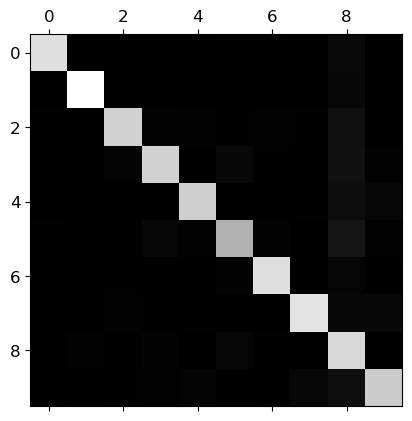

In [57]:
# Plotting a heatmap
plt.matshow(confusion_mx,cmap=plt.cm.gray)
plt.show()

In [60]:
# Getting error rates
row_sums = confusion_mx.sum(axis=1, keepdims=True) # Each True class sum
row_sums

array([[5923],
       [6742],
       [5958],
       [6131],
       [5842],
       [5421],
       [5918],
       [6265],
       [5851],
       [5949]])

In [64]:
norm_conf_mx = confusion_mx / row_sums
norm_conf_mx

array([[9.41583657e-01, 0.00000000e+00, 3.71433395e-03, 8.44166807e-04,
        1.35066689e-03, 7.25983454e-03, 6.07800101e-03, 1.01300017e-03,
        3.79875063e-02, 1.68833361e-04],
       [0.00000000e+00, 9.49273213e-01, 5.48798576e-03, 3.55977455e-03,
        5.93295758e-04, 6.52625334e-03, 5.93295758e-04, 1.03826758e-03,
        3.14446752e-02, 1.48323939e-03],
       [4.53172205e-03, 4.53172205e-03, 8.76132931e-01, 1.54414233e-02,
        1.22524337e-02, 4.53172205e-03, 1.12453844e-02, 6.04229607e-03,
        6.34441088e-02, 1.84625713e-03],
       [3.58832164e-03, 2.77279400e-03, 1.90833469e-02, 8.52552602e-01,
        3.26211059e-04, 3.31104224e-02, 4.40384929e-03, 6.52422117e-03,
        6.57315283e-02, 1.19067036e-02],
       [2.05409106e-03, 2.39643958e-03, 7.01814447e-03, 1.54056830e-03,
        8.87024991e-01, 2.05409106e-03, 5.81992468e-03, 4.62170490e-03,
        5.93974666e-02, 2.80725779e-02],
       [4.98063088e-03, 2.76701716e-03, 5.53403431e-03, 3.09905921e-02,
   

In [65]:
# Fill diagonals with 0
np.fill_diagonal(norm_conf_mx,0)
norm_conf_mx

array([[0.        , 0.        , 0.00371433, 0.00084417, 0.00135067,
        0.00725983, 0.006078  , 0.001013  , 0.03798751, 0.00016883],
       [0.        , 0.        , 0.00548799, 0.00355977, 0.0005933 ,
        0.00652625, 0.0005933 , 0.00103827, 0.03144468, 0.00148324],
       [0.00453172, 0.00453172, 0.        , 0.01544142, 0.01225243,
        0.00453172, 0.01124538, 0.0060423 , 0.06344411, 0.00184626],
       [0.00358832, 0.00277279, 0.01908335, 0.        , 0.00032621,
        0.03311042, 0.00440385, 0.00652422, 0.06573153, 0.0119067 ],
       [0.00205409, 0.00239644, 0.00701814, 0.00154057, 0.        ,
        0.00205409, 0.00581992, 0.0046217 , 0.05939747, 0.02807258],
       [0.00498063, 0.00276702, 0.00553403, 0.03099059, 0.00977679,
        0.        , 0.01383509, 0.00258255, 0.09869028, 0.01106807],
       [0.00506928, 0.00253464, 0.00709699, 0.00050693, 0.00743494,
        0.01639067, 0.        , 0.00050693, 0.02213586, 0.00016898],
       [0.00335196, 0.00159617, 0.0081404

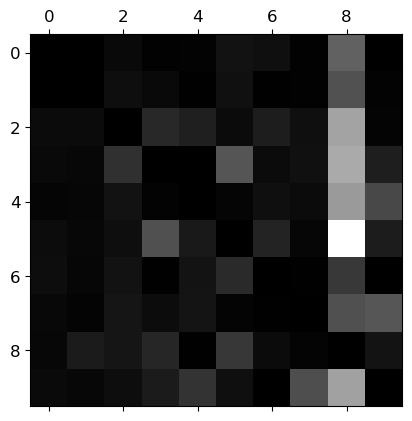

In [66]:
plt.matshow(norm_conf_mx,cmap=plt.cm.gray)
plt.show()